# Machine Learning Final Project

## **Chronic Kidney Disease Prediction Using Machine Learning**

## **Course:** ISDS 7075E  
## **Team Members:** Thais Diaz, Rhonda Swider, Cody Tatom 





# BACKGROUND

<div style="width: 90%; margin: auto; text-align: justify; font-size: 16px;">
  <i><b>"Chronic kidney disease (CKD)</b> is a significant public health concern in the United States. According to the CDC, approximately 37 million U.S. adults, or 14% of the adult population, are estimated to have CKD. Of particular concern, approximately 87% of adults with CKD are unaware that they have the condition. CKD has also been strongly associated with diabetes, hypertension, and increasing age. These findings highlight the importance of identifying measurable factors that may help distinguish individuals with CKD and support earlier detection."</i>
</div>

In [1]:
from IPython.display import Image, display

display(Image(url='https://raw.githubusercontent.com/rcswider/Chronic-Kidney-Disease/refs/heads/main/images/87_percent_unaware.png',width=500))

  **Reference:**  Centers for Disease Control and Prevention. (2026). Chronic Kidney Disease in the United States. Atlanta, GA: U.S. Department of Health and Human Services, Centers for Disease Control and Prevention.

# PROJECT OBJECTIVE

The business objective of this project is to determine whether patient clinical and laboratory information can be used to identify Chronic Kidney Disease. A reliable model could support healthcare providers by helping them identify higher-risk patients more quickly. The model would support, rather than replace, medical judgment.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# PART 1 – DATA EXPLORATION AND DATA WRANGLING

## IMPORT THE DATA

The Chronic Kidney Disease dataset and the accompanying data dictionary are imported into Python to begin the analysis. Loading both files allows the project to use the patient data for modeling while also providing a reference for understanding the variables included in the dataset.

In [3]:
df_kd = pd.read_excel("https://github.com/rcswider/Chronic-Kidney-Disease/blob/main/data/ML_project_kidney_disease.xlsx?raw=True")
df_kd_fields = pd.read_excel("https://github.com/rcswider/Chronic-Kidney-Disease/blob/main/data/ML_project_kidney_disease.xlsx?raw=True", sheet_name = "Fields")

## DATA EXPLORATION

# Preview the Dataset

The first 15 records are displayed to become familiar with the dataset and verify that it loaded correctly. Reviewing the initial records helps identify the variables available for analysis, understand how the data is organized, and detect any obvious data quality issues before beginning the exploration and preprocessing steps.


In [4]:
df_kd.head(15)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,wc,rc,htn,dm,cad,appet,pe,ane,classification,CKD_class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,6000,NaN,no,no,no,good,no,no,ckd,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,7500,NaN,no,yes,no,poor,no,yes,ckd,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,7300,4.6,no,no,no,good,no,no,ckd,1
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,7800,4.4,yes,yes,no,good,yes,no,ckd,1
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,NaN,NaN,no,no,no,good,no,no,ckd,1
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,6900,5,no,yes,no,good,yes,no,ckd,1
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,9600,4,yes,yes,no,good,no,yes,ckd,1
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,12100,3.7,yes,yes,no,poor,no,yes,ckd,1


### Observations 

- The dataset contains both numerical and categorical variables related to patient health.
  Some variables contain missing values, which will need to be addressed before building the machine   learning model.
- The dataset includes two variables that identify the diagnosis (classification and CKD_class), so one of them will be removed during data wrangling to avoid duplicate information.
- Based on this initial review, the next step is to examine the dataset structure and evaluate the overall quality of the data.

# Explore the Dataset Structure

The dataset structure is reviewed to understand the number of records, the available variables, their data types, and the presence of missing values. This information is important because it helps determine which preprocessing steps will be needed before training the machine learning models.

In [5]:
df_kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

### Observations 

- The dataset contains 400 patient records and 27 variables.
- Both numerical and categorical variables are present, so some categorical variables will need to be converted into numeric values before model training.
- Several variables contain missing values, indicating that data imputation will be required instead of removing a large number of records.
- Two variables (classification and CKD_class) represent the same diagnosis. Since CKD_class is already stored as numeric values (0 and 1), it will be used as the target variable and classification will be removed during data wrangling.

## Summary Statistics

Summary statistics are reviewed to better understand the numerical variables in the dataset. This step helps identify the range of values, central tendency, variability, and any potential outliers that may influence data preprocessing and model performance.

In [6]:
df_kd.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,CKD_class
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.620000
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.485994
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,0.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


### Observations 

- The numerical variables have different ranges and distributions.
- Some variables, such as blood glucose (bgr), blood urea (bu), and serum creatinine (sc), have maximum values that are much higher than their median values, suggesting the presence of outliers or right-skewed distributions.
- The id column is only a unique identifier and does not provide information useful for predicting Chronic Kidney Disease.
- These findings suggest that some numerical variables may require imputation and, depending on the machine learning model selected, scaling or normalization during data preprocessing.

### Investigate Data Dictionary

The data dictionary is included as the second worksheet in the Excel file. It provides a description of each variable, its data type, and the possible values for each field. Reviewing the data dictionary helps identify which variables are numerical, categorical, binary, or continuous, and supports decisions about data preprocessing before building the machine learning models.

In [7]:
df_kd_fields

,Name,Description,Type,value_info
0,age,age,Integer,age in years
1,bp,blood pressure,Integer,bp in mm/Hg
2,sg,specific gravity,Categorical,"1.005,1.010,1.015,1.020,1.025"
3,al,albumin,Categorical,"0,1,2,3,4,5"
4,su,sugar,Categorical,"0,1,2,3,4,5"
5,rbc,red blood cells,Binary,"normal,abnormal"
6,pc,pus cell,Binary,"normal,abnormal"
7,pcc,pus cell clumps,Binary,"present,notpresent"
8,ba,bacteria,Binary,"present,notpresent"
9,bgr,blood gluucose random,Integer,bgr in mgs/dl


### Observations

- The data dictionary provides the name, description, data type, and possible values for each variable.
- The dataset contains integer, continuous, categorical, and binary variables, so different preprocessing techniques will be needed.
- Several variables are binary and contain values such as yes/no, normal/abnormal, and present/notpresent. These variables will need to be converted into numerical values before training most machine learning models.
- The data dictionary confirms that classification (or class) and CKD_class represent the same diagnosis. Since `CKD_class` is already encoded as 0 and 1, it will be used as the target variable, and the duplicate diagnosis column will be removed during data wrangling.

### Identify Missing Values

Missing values are identified to evaluate the overall quality of the dataset and determine which variables will require preprocessing. Understanding the amount of missing data helps decide whether values should be imputed or if any variables require additional attention before building the machine learning models.

In [8]:
df_kd.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
CKD_class           0
dtype: int64

### Observations

- Several variables contain missing values, while others are complete.
The largest number of missing values is found in rbc (152), rc (130), and wc (105). Other variables, such as sod (87) and pot (88), also contain a substantial amount of missing data.
- The target variable (CKD_class) and the duplicate diagnosis column (classification) do not contain missing values.
- Because the dataset contains only 400 patient records, removing all rows with missing values would significantly reduce the amount of data available for training. Based on these findings, missing values will be handled through imputation during the data wrangling phase rather than deleting records.

## Visualize the Target Variable: 

The target variable is visualized to examine the distribution of patients with and without Chronic Kidney Disease (CKD). Understanding the class distribution helps determine whether the dataset is balanced and whether additional preprocessing techniques, such as class balancing, may be needed before training the machine learning models.

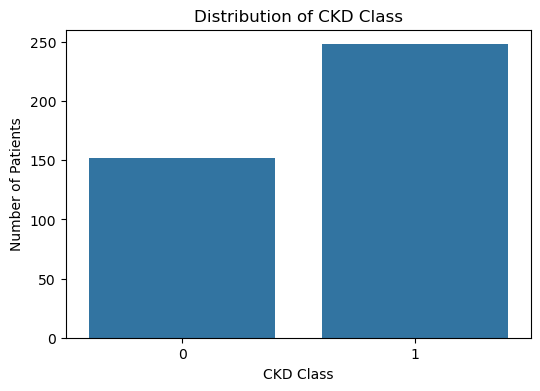

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='CKD_class', data=df_kd)

plt.title('Distribution of CKD Class')
plt.xlabel('CKD Class')
plt.ylabel('Number of Patients')

plt.show()

### Observations

- The target variable shows that the dataset contains more patients with Chronic Kidney Disease (CKD_class = 1) than patients without the disease (CKD_class = 0).
- Although the classes are not perfectly balanced, both groups contain a sufficient number of observations for model training and evaluation.
- Because there is a moderate class imbalance, model performance will be evaluated using metrics such as precision, recall, and F1-score, in addition to accuracy, to ensure the model performs well for both classes.

## Explore Numerical Variables

Histograms are used to examine the distribution of the numerical variables in the dataset. Reviewing these distributions helps identify skewed variables, potential outliers, and differences in value ranges. These observations help determine whether additional preprocessing steps, such as scaling or different imputation methods, may be needed before model training.

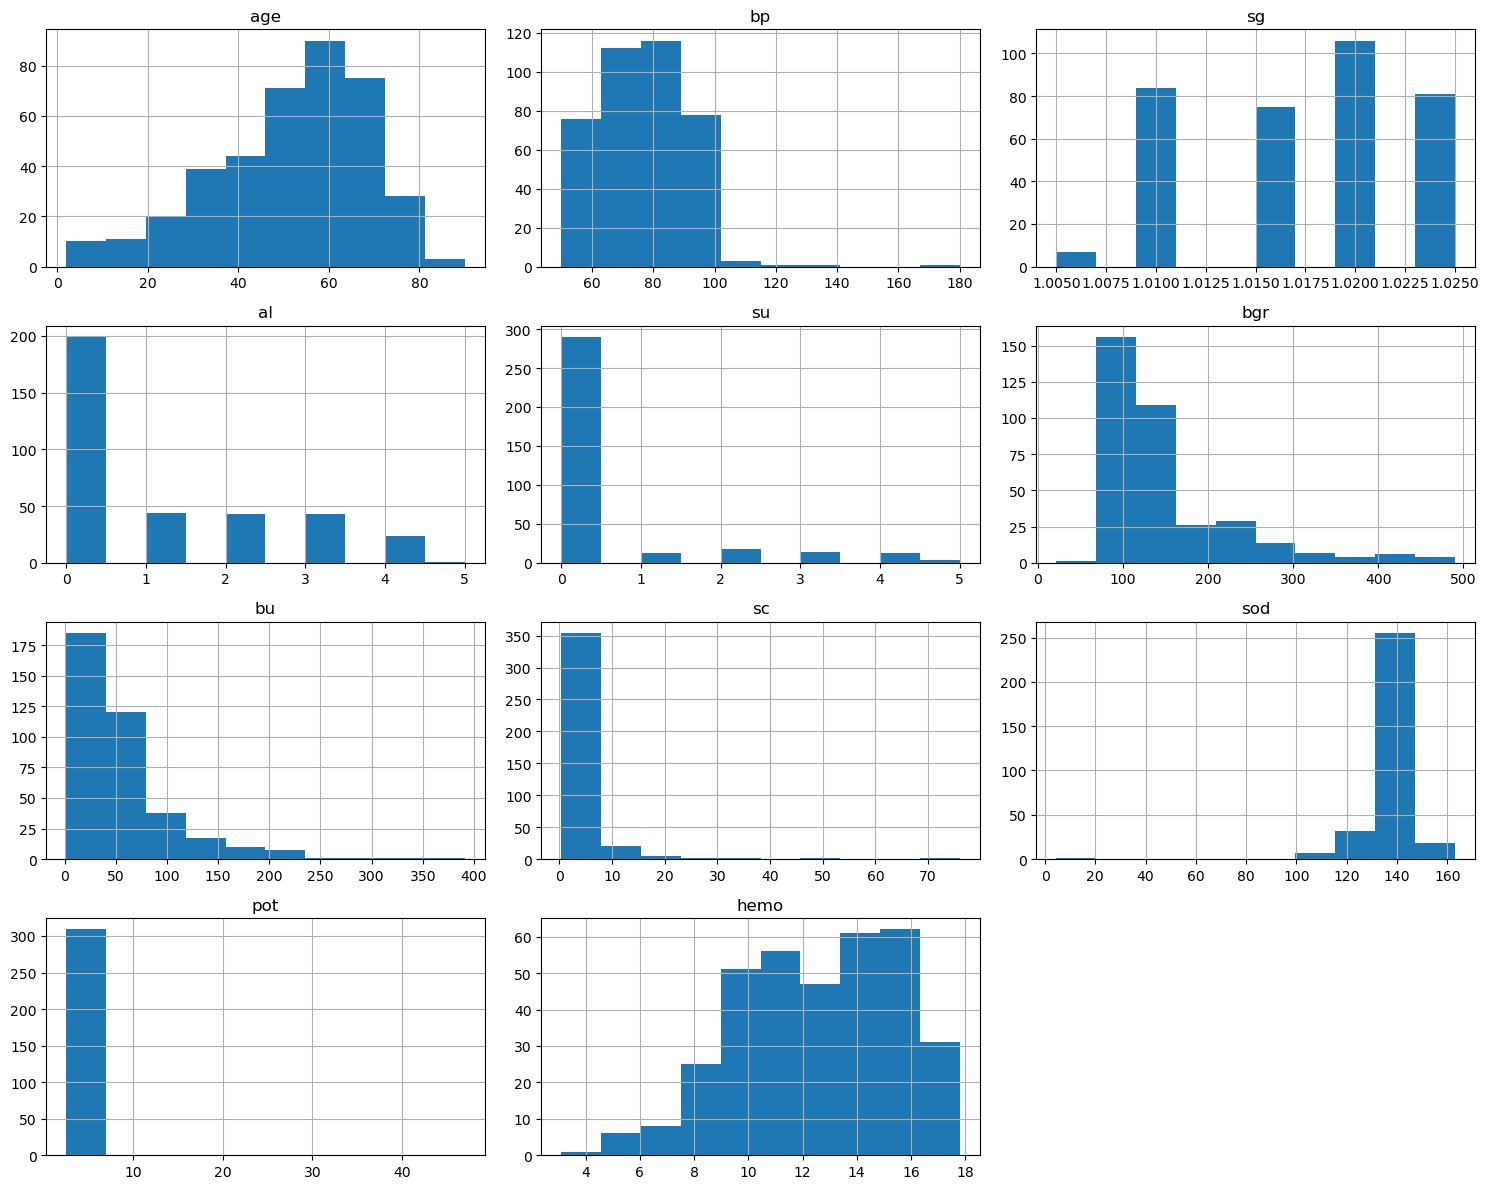

In [10]:
# Exclude the ID and target variable from the histograms
df_hist = df_kd.drop(columns=["id", "CKD_class"])

# Display histograms for the remaining numerical variables
df_hist.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

### Observations

- The histograms show that the numerical variables have different distributions and value ranges across the dataset.
- Variables such as blood glucose (bgr), blood urea (bu), and serum creatinine (sc) appear to have right-skewed distributions with several high values, suggesting the presence of potential outliers that should be considered during data preprocessing.
- Variables such as age and hemoglobin (hemo) appear to have more balanced distributions.
- These findings suggest that different preprocessing techniques may be appropriate for different variables. During the data wrangling phase, these distributions will be considered when selecting imputation methods and determining whether scaling is needed for the machine learning models.

## Correlation Analysis

The correlation matrix is used to examine the relationships between the numerical variables in the dataset. Identifying strong positive or negative correlations helps determine which variables may be important predictors of Chronic Kidney Disease and whether some variables provide similar information that can be considered during feature selection.

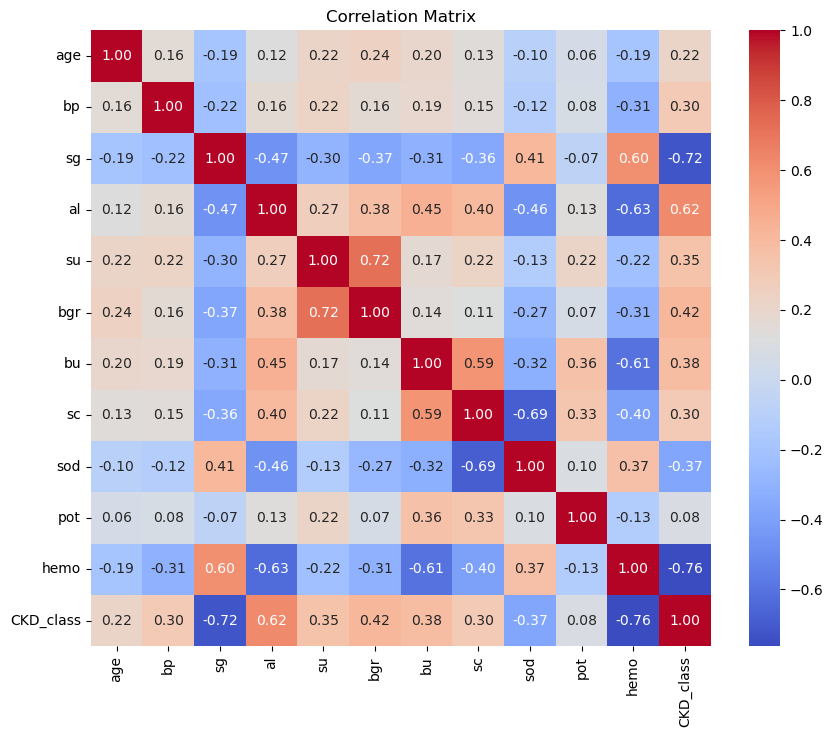

In [11]:
# Exclude the ID column from the correlation analysis
corr_data = df_kd.drop(columns=["id"])

# Calculate correlations for numerical variables
correlation = corr_data.corr(numeric_only=True)

# Create the correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observations

- The correlation matrix shows that several numerical variables have moderate to strong correlations with the target variable (CKD_class).
- Hemoglobin (hemo) and specific gravity (sg) have the strongest negative correlations with CKD_class, while albumin (al) has one of the strongest positive correlations. These variables may be important predictors of Chronic Kidney Disease.
- Some predictor variables are also correlated with one another. For example, sugar (su) and blood glucose (bgr) have a strong positive correlation, while blood urea (bu) and serum creatinine (sc) are also positively correlated. These relationships suggest that some variables provide similar information.
- The correlation analysis provides additional insight into the relationships among the variables and will help guide feature selection during the machine learning phase. This information will help identify the variables that contribute the most to predicting Chronic Kidney Disease.

## DATA WRANGLING

# Create a working copy

A working copy of the dataset is created so the original data remains unchanged during data wrangling. This allows preprocessing steps to be completed safely while preserving the original dataset for comparison or review if needed.

In [12]:
df_clean = df_kd.copy()

### Observation 

The working copy was created successfully. All remaining data wrangling steps will be completed using df_clean instead of modifying the original dataset.

# Remove unnecessary columns

Some columns do not provide useful information for training the machine learning model. Removing these columns reduces redundancy and ensures that only relevant features are used during model development.

id is a unique identifier and does not contain information that helps predict Chronic Kidney Disease.

classification contains the same diagnosis as CKD_class. Since CKD_class is already encoded as 0 and 1, it will be used as the target variable, making classification unnecessary.

In [13]:
df_clean = df_clean.drop("id", axis=1)
df_clean = df_clean.drop("classification", axis=1)

### Observation

- The id and classification columns were removed from the working dataset. This leaves only the predictor variables and the selected target variable (CKD_class), reducing duplicate information and preparing the dataset for preprocessing and model development.

# Adjust Invalid Values and Convert Data Types

The dataset contains formatting inconsistencies that prevent some variables from being interpreted correctly. Tabs, extra spaces, and question marks (?) are removed or replaced so the data can be processed consistently. In addition, the wc, pcv, and rc columns are converted to numeric data types because they will be used as numerical predictor variables during model development.

In [14]:
# Remove tabs and extra spaces from the dataset
df_clean = df_clean.replace("\t", "", regex=True)
df_clean = df_clean.replace(" ", "", regex=True)

# Replace "?" with missing values (NaN)
df_clean = df_clean.replace("?", np.nan)

# Convert selected columns to numeric data types
df_clean[["wc", "pcv", "rc"]] = df_clean[["wc", "pcv", "rc"]].astype("float64")

C:\Users\ctato\AppData\Local\Temp\ipykernel_1720\3087290796.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df_clean.replace("?", np.nan)


### Observation

The formatting inconsistencies were successfully removed, missing values represented by "?" were converted to NaN, and the wc, pcv, and rc columns were converted to numeric data types. These changes ensure the dataset is consistent and ready for the remaining preprocessing and machine learning tasks.

# Adjust for Missing Values

Missing values must be handled before training a machine learning model because most algorithms cannot process incomplete data. Different imputation methods are used based on the type and distribution of each variable. Numerical variables are filled with either the median or the mean, while categorical and binary variables are filled with the most frequent value (mode). These methods help preserve the dataset while minimizing the impact of missing data.

In [15]:
# Impute missing variables

df_clean['age'] = df_clean.age.fillna(df_clean.age.median())
df_clean['bp'] = df_clean.bp.fillna(df_clean.bp.mean())
df_clean['bgr'] = df_clean.bgr.fillna(df_clean.bgr.median())
df_clean['bu'] = df_clean.bu.fillna(df_clean.bu.median())
df_clean['sc'] = df_clean.sc.fillna(df_clean.sc.median())
df_clean['sod'] = df_clean.sod.fillna(df_clean.sod.mean())
df_clean['pot'] = df_clean.pot.fillna(df_clean.pot.mean())
df_clean['hemo'] = df_clean.hemo.fillna(df_clean.hemo.mean())
df_clean['pcv'] = df_clean.pcv.fillna(df_clean.pcv.mean())
df_clean['wc'] = df_clean.wc.fillna(df_clean.wc.mean())
df_clean['rc'] = df_clean.rc.fillna(df_clean.rc.mean())

df_clean['sg'] = df_clean.sg.fillna(df_clean.sg.mode()[0])
df_clean['al'] = df_clean.al.fillna(df_clean.al.mode()[0])
df_clean['su'] = df_clean.su.fillna(df_clean.su.mode()[0])
df_clean['rbc'] = df_clean.rbc.fillna(df_clean.rbc.mode()[0])
df_clean['pc'] = df_clean.pc.fillna(df_clean.pc.mode()[0])
df_clean['pcc'] = df_clean.pcc.fillna(df_clean.pcc.mode()[0])
df_clean['ba'] = df_clean.ba.fillna(df_clean.ba.mode()[0])
df_clean['htn'] = df_clean.htn.fillna(df_clean.htn.mode()[0])
df_clean['dm'] = df_clean.dm.fillna(df_clean.dm.mode()[0])
df_clean['cad'] = df_clean.cad.fillna(df_clean.cad.mode()[0])
df_clean['appet'] = df_clean.appet.fillna(df_clean.appet.mode()[0])
df_clean['pe'] = df_clean.pe.fillna(df_clean.pe.mode()[0])
df_clean['ane'] = df_clean.ane.fillna(df_clean.ane.mode()[0])


### Observation
- Missing values were successfully replaced using imputation methods appropriate for each variable type.
- The median was used for age, bgr, bu, and sc because their distributions in doing so are less affected by extreme values.
- The mean was used for the remaining numerical variables to preserve their overall distribution.
- The mode was used for categorical and binary variables because it replaces missing values with the most common category.
- After this step, the dataset contains complete values and is ready for the remaining preprocessing and machine learning tasks.

## Verify Data Quality After Imputation

After replacing the missing values, the dataset is reviewed again to verify that the imputation was successful. This step confirms that all variables contain complete data and that the data types are appropriate before continuing with feature engineering and model development.

In [16]:
df_clean.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        400 non-null    float64
 1   bp         400 non-null    float64
 2   sg         400 non-null    float64
 3   al         400 non-null    float64
 4   su         400 non-null    float64
 5   rbc        400 non-null    object 
 6   pc         400 non-null    object 
 7   pcc        400 non-null    object 
 8   ba         400 non-null    object 
 9   bgr        400 non-null    float64
 10  bu         400 non-null    float64
 11  sc         400 non-null    float64
 12  sod        400 non-null    float64
 13  pot        400 non-null    float64
 14  hemo       400 non-null    float64
 15  pcv        400 non-null    float64
 16  wc         400 non-null    float64
 17  rc         400 non-null    float64
 18  htn        400 non-null    object 
 19  dm         400 non-null    object 
 20  cad       

### Observation

The dataset now contains 400 complete records for every variable, confirming that all missing values have been successfully handled. The numerical variables have the appropriate numeric data types, while the categorical and binary variables remain as object data types and will be encoded before training the machine learning models.

## Normalization

Normalization is used to scale numerical variables so they have a consistent range. This can improve the performance of some machine learning algorithms by preventing variables with large values from having a greater influence than variables with smaller values. The variables wc, bgr, bu, sc, hemo, pcv, and rc  were normalized due to having a much larger range than the other numerical variables.

In [17]:
# Normalize variables
# replace (original value) by (original value)/(maximum value)
df_clean['wc'] = df_clean['wc']/df_clean['wc'].max()
df_clean['bgr'] = df_clean['bgr']/df_clean['bgr'].max()
df_clean['bu'] = df_clean['bu']/df_clean['bu'].max()
df_clean['sc'] = df_clean['sc']/df_clean['sc'].max()
df_clean['hemo'] = df_clean['hemo']/df_clean['hemo'].max()
df_clean['pcv'] = df_clean['pcv']/df_clean['pcv'].max()
df_clean['rc'] = df_clean['rc']/df_clean['rc'].max()

### Observation

The variables were successfully normalized by dividing each value by the maximum value in the column. This scales the data between 0 and 1 while preserving the relative differences between observations. The normalized variable is now more comparable with other numerical features and may improve the performance of machine learning models that are sensitive to differences in feature scales.

## Binning

Binning is used to group continuous numerical values into meaningful categories. In this project, the age variable is divided into age groups to simplify the data and determine whether broader age ranges provide useful information for predicting Chronic Kidney Disease. This may also make the model easier to interpret.


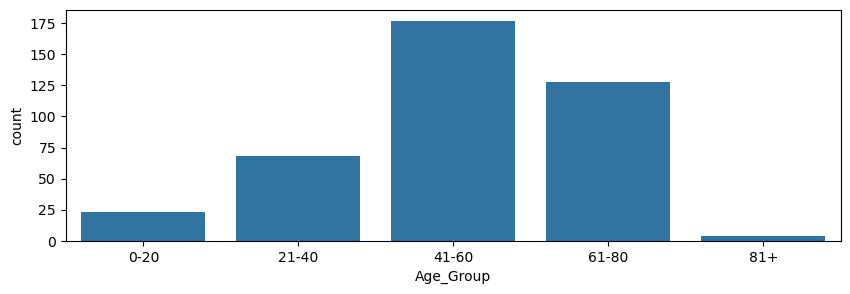

In [18]:
# Binning the age variable
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81+']

df_clean['Age_Group'] = pd.cut(
    df_clean['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(10,3))
sns.countplot(x=df_clean['Age_Group'])
plt.show()

### Observation

The Age_Group column was successfully created by grouping patients into five age categories while retaining the original age variable. Most patients fall within the 41–60 and 61–80 age groups, while relatively few patients are younger than 20 or older than 80. Keeping both variables allows the machine learning models to evaluate whether the continuous age or the grouped age provides better predictive performance.

## Separate the Features and target variable
The dataset contains two columns that identify whether a patient has chronic kidney disease: classification and CKD_class. Since both columns represent the same diagnosis, CKD_class is used as the target variable because it is already coded as 0 and 1. The classification column is removed from the input features to avoid including duplicate information when building the machine learning model.

In [19]:
X = df_clean.drop("CKD_class", axis=1)

y = df_clean["CKD_class"]

### Observation

- The predictor variables were successfully separated from the target variable.
- X contains all of the input features that will be used to train the machine learning models.
- y contains the CKD_class target variable, which represents whether a patient has Chronic Kidney Disease.
- Separating the predictors from the target prepares the dataset for the train-test split and model development.

## Create the training and testing datasets

Before training a machine learning model, the dataset is divided into training and testing sets. The training dataset is used to build the model, while the testing dataset is used to evaluate how well the model performs on unseen data. In this project, 80% of the data is used for training and 20% is reserved for testing.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [21]:
print(X_train.shape)
print(X_test.shape)

(320, 25)
(80, 25)


### Observation

The dataset was successfully divided into training and testing datasets using an 80/20 split. The training dataset contains 320 observations, while the testing dataset contains 80 observations. This separation allows the machine learning models to be trained on one portion of the data and evaluated on a separate, unseen dataset to better assess model performance.

# PROJECT PART 1 – SUMMARY

The dataset was successfully explored and prepared for machine learning. The exploratory analysis provided a better understanding of the data structure, variable distributions, relationships between numerical features, and the quality of the dataset. During data wrangling, a working copy was created, unnecessary columns were removed, formatting inconsistencies were corrected, missing values were handled, the Age_Group column was created through binning, and the predictor and target variables were separated. Finally, the dataset was divided into training and testing datasets to prepare for the model development phase.

The remaining preprocessing steps include converting the categorical variables into numerical values, evaluating feature importance, training multiple machine learning models, and comparing their performance to identify the best model for predicting Chronic Kidney Disease.

____________________________________

# PART 2 – MACHINE LEARNING MODEL

Part 2 focuses on developing, evaluating, and comparing machine learning models to predict Chronic Kidney Disease (CKD). The cleaned and prepared dataset from Part 1 is used to train several classification models, evaluate their performance using standard metrics, and determine which model provides the most accurate predictions. The best-performing model will be selected based on its overall performance and ability to correctly classify patients with and without CKD.

## LOGISTIC REGRESSION

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. In this project, it is used to classify patients as having or not having Chronic Kidney Disease (CKD). Logistic Regression estimates the probability that a patient belongs to the CKD class and serves as an interpretable baseline model for comparison with the other machine learning algorithms evaluated in this project.

## Train the Logistic Regression Model

The Logistic Regression model is trained using the encoded training dataset prepared earlier. A machine learning pipeline is used to simplify preprocessing and model training. The pipeline applies median imputation for any remaining missing values, standardizes the predictor variables, and then fits the Logistic Regression classifier. Standardization is performed because Logistic Regression generally performs better when numerical features are on a similar scale.

## Import Required Libraries

The following libraries are imported to build and evaluate the Logistic Regression model. These libraries provide the tools needed to preprocess the data, train the classifier, and evaluate its performance.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

##  Create and Train the Logistic Regression Model

The Logistic Regression model is created using a machine learning pipeline that combines data preprocessing and model training into a single workflow. The pipeline first replaces any remaining missing values using median imputation, then standardizes the predictor variables, and finally trains the Logistic Regression classifier. This approach ensures that the same preprocessing steps are consistently applied whenever the model is trained or used to make predictions.

In [23]:
# Convert categorical predictor variables into numerical dummy variables
X_encoded = pd.get_dummies(X, dtype=int)

# Create updated training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the updated dataset shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


Training features: (320, 39)
Testing features: (80, 39)
Training target: (320,)
Testing target: (80,)


In [24]:
# Create the Logistic Regression pipeline
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train the Logistic Regression model
logistic_model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


### Observations

- The Logistic Regression pipeline was successfully created and trained using the encoded training dataset.
- The pipeline automatically applied median imputation to handle any remaining missing values and standardized the predictor variables before training the classifier.
- Combining preprocessing and model training into a single pipeline ensures that the same transformations are consistently applied during both training and prediction.
- The trained Logistic Regression model is now ready to generate predictions and evaluate its performance using the testing dataset.

## Generate Predictions

After training the Logistic Regression model, predictions are generated for the testing dataset. These predictions are compared with the actual CKD classifications to assess how well the model performs on previously unseen data.

In [25]:
# Generate predictions using the testing dataset
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:,1]

logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

# Display the first 10 predictions
print("First 10 Predictions:", y_pred_logistic[:10])

# Display the first 10 actual values
print("First 10 Actual Values:", y_test.values[:10])

First 10 Predictions: [0 1 1 0 1 1 0 1 1 1]
First 10 Actual Values: [0 1 1 0 1 1 0 1 1 1]


### Observations

- The Logistic Regression model successfully generated predictions for the testing dataset.
- The first 10 predictions matched all 10 actual classifications.
- This initial comparison is promising, but the model must still be evaluated across the full testing dataset using accuracy, precision, recall, F1 score, and a confusion matrix.

## Evaluate the Logistic Regression Model

The Logistic Regression model is evaluated using standard classification metrics, including accuracy, precision, recall, F1 score, and the confusion matrix. These metrics provide a complete assessment of how effectively the model classifies patients with and without Chronic Kidney Disease and allow its performance to be compared with the Random Forest model.

In [26]:
# Calculate model accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Accuracy:", logistic_accuracy)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.9875

Confusion Matrix:
[[29  1]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



### Observations

- The Logistic Regression model achieved an accuracy of 98.75%, correctly classifying 79 of the 80 testing observations.
- The confusion matrix shows that the model correctly identified all 50 CKD cases, resulting in a recall of 100% for the CKD class. Only one non-CKD case was incorrectly classified as CKD.
- The classification report demonstrates excellent overall performance, with a precision of 98%, recall of 100%, and an F1 score of 99% for the CKD class. These results indicate that the Logistic Regression model is highly effective at identifying patients with Chronic Kidney Disease while maintaining strong overall predictive performance.

## DECISION TREE CLASSIFIER

A Decision Tree is a supervised machine learning algorithm that classifies data by creating a series of decision rules based on the predictor variables. The model recursively splits the dataset into smaller groups to improve classification accuracy. In this project, the Decision Tree classifier is used to predict whether a patient has Chronic Kidney Disease (CKD) and to compare its performance with the Random Forest and Logistic Regression models.

## Import Required Libraries

The following library is imported to create and train the Decision Tree classifier. This algorithm builds a tree-like structure of decision rules that can be used to classify patients with and without Chronic Kidney Disease.

In [27]:
from sklearn.tree import DecisionTreeClassifier

## Create and Train the Decision Tree Model

The Decision Tree classifier is created using the encoded training dataset prepared earlier. The model learns a series of decision rules from the training data to classify patients into the CKD and non-CKD groups. The trained model will then be used to generate predictions for the testing dataset.

In [28]:
# Create the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Observations

- The Decision Tree classifier was successfully created and trained using the encoded training dataset.
- During training, the model learned a series of decision rules based on the predictor variables to classify patients with and without Chronic Kidney Disease.
- The trained Decision Tree model is now ready to generate predictions and evaluate its performance using the testing dataset.

## Generate Predictions

After training the Decision Tree classifier, predictions are generated for the testing dataset. These predictions are compared with the actual CKD classifications to provide an initial assessment of the model's performance before calculating the full evaluation metrics.

In [29]:
# Generate predictions using the testing dataset
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

# Display the first 10 predictions
print("First 10 Predictions:", y_pred_dt[:10])

# Display the first 10 actual values
print("First 10 Actual Values:", y_test.values[:10])

First 10 Predictions: [0 1 0 0 1 1 0 1 1 1]
First 10 Actual Values: [0 1 1 0 1 1 0 1 1 1]


### Observations

- The Decision Tree classifier successfully generated predictions for the testing dataset.
- The first 10 predictions correctly classified 9 of the first 10 testing observations, demonstrating that the model learned meaningful decision patterns from the training data.
- Although the initial predictions are promising, the model's overall performance must be evaluated using classification metrics and the confusion matrix to assess its effectiveness across the entire testing dataset.

## Evaluate the Decision Tree Model

The Decision Tree classifier is evaluated using standard classification metrics, including accuracy, precision, recall, F1 score, and the confusion matrix. These metrics provide a comprehensive assessment of the model's ability to correctly classify patients with and without Chronic Kidney Disease and allow its performance to be compared with the other machine learning models developed in this project.

In [30]:
# Calculate model accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", dt_accuracy)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.95

Confusion Matrix:
[[28  2]
 [ 2 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.96      0.96      0.96        50

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



### Observations

- The Decision Tree classifier achieved an accuracy of 95.0%, correctly classifying 76 of the 80 testing observations.
- The confusion matrix shows that the model correctly identified 28 of 30 non-CKD patients and 48 of 50 CKD patients, with two misclassifications in each class.
- The classification report indicates balanced performance, with precision, recall, and F1-scores ranging from 93% to 96% across both classes.
- Although the Decision Tree model performed well, its overall accuracy was lower than both the Random Forest (97.5%) and Logistic Regression (98.75%) models evaluated earlier. This suggests that the single Decision Tree may be more susceptible to overfitting and less robust than the ensemble and linear models.

## TUNED DECISION TREE CLASSIFIER

A tuned Decision Tree classifier is developed to improve the performance of the baseline Decision Tree model. Instead of using the default settings, multiple combinations of hyperparameters are evaluated using GridSearchCV with five-fold cross-validation. The combination that produces the best performance is selected and used to train the final tuned Decision Tree model.

## Import Required Libraries

The following library is imported to perform hyperparameter tuning using GridSearchCV. This method systematically evaluates multiple combinations of Decision Tree parameters to identify the configuration that provides the best model performance.

In [31]:
from sklearn.model_selection import GridSearchCV

## Tune and Train the Decision Tree Model

GridSearchCV is used to evaluate different combinations of Decision Tree hyperparameters, including the maximum tree depth, minimum number of samples required to split a node, and minimum number of samples required in each leaf. Five-fold cross-validation is used during the search, and recall is selected as the optimization metric because correctly identifying CKD patients is a primary objective of this project.

In [32]:
# Define the parameter grid
dt_param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Train the Grid Search
dt_grid.fit(X_train, y_train)

# Select the best model
dt_tuned = dt_grid.best_estimator_

# Display the selected parameters
print("Best Parameters:", dt_grid.best_params_)
print("Best Cross-Validation Recall:", round(dt_grid.best_score_, 3))
print("Tree Depth:", dt_tuned.get_depth())
print("Number of Leaves:", dt_tuned.get_n_leaves())

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Recall: 0.99
Tree Depth: 3
Number of Leaves: 7


### Observations

- GridSearchCV selected a maximum depth of 3, a minimum leaf size of 1, and a minimum split size of 2.
- The best five-fold cross-validation recall was 0.99, indicating that the tuned model performed very well at identifying CKD cases during training validation.
- The selected tree has a depth of 3 and 7 leaves, making it relatively simple and easier to interpret.
- Limiting the tree depth helps reduce overfitting while preserving strong recall.

## Generate Predictions

After tuning the Decision Tree classifier, predictions are generated using the testing dataset. These predictions are compared with the actual CKD classifications to provide an initial assessment of the tuned model's performance on previously unseen data before calculating the full evaluation metrics.

In [33]:
# Generate predictions using the tuned Decision Tree
y_pred_dt_tuned = dt_tuned.predict(X_test)
y_prob_dt_tuned = dt_tuned.predict_proba(X_test)[:,1]

dt_tuned_roc_auc = roc_auc_score(y_test, y_prob_dt_tuned)

# Display the first 10 predictions
print("First 10 Predictions:", y_pred_dt_tuned[:10])

# Display the first 10 actual values
print("First 10 Actual Values:", y_test.values[:10])

First 10 Predictions: [0 1 0 0 1 1 0 1 1 1]
First 10 Actual Values: [0 1 1 0 1 1 0 1 1 1]


### Observations

- The tuned Decision Tree classifier successfully generated predictions for the testing dataset.
- The first 10 predictions correctly classified 9 of the first 10 testing observations, demonstrating that the tuned model effectively learned decision patterns from the training data.
- Although the initial predictions are encouraging, the model's overall performance should be evaluated using accuracy, precision, recall, F1 score, and the confusion matrix to determine whether tuning improved the classifier.

## Evaluate the Tuned Decision Tree Model 

The tuned Decision Tree classifier is evaluated using standard classification metrics, including accuracy, precision, recall, F1 score, and the confusion matrix. These metrics measure the model's ability to correctly classify patients with and without Chronic Kidney Disease (CKD) and help determine whether hyperparameter tuning improved performance compared with the baseline Decision Tree classifier.

In [34]:
# Calculate model accuracy
dt_tuned_accuracy = accuracy_score(y_test, y_pred_dt_tuned)

print("Accuracy:", dt_tuned_accuracy)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_tuned))

Accuracy: 0.95

Confusion Matrix:
[[28  2]
 [ 2 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.96      0.96      0.96        50

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



### Observations

- The tuned Decision Tree classifier achieved an accuracy of 95.0%, correctly classifying 76 of the 80 testing observations.
- The confusion matrix shows that the model correctly identified 28 of 30 non-CKD patients and 48 of 50 CKD patients, with two misclassifications in each class.
- The classification report indicates balanced performance, with precision, recall, and F1-scores ranging from 93% to 96% across both classes.
- Although hyperparameter tuning produced a simpler and more interpretable tree, the overall testing performance remained essentially unchanged compared with the baseline Decision Tree classifier. This suggests that the original model was already close to the optimal configuration for this dataset.

## Visualize the Tuned Decision Tree

Visualizing the tuned Decision Tree provides a graphical representation of the decision rules learned during training. The simplified tree makes it easier to interpret how the model classifies patients based on the most important predictor variables and demonstrates the effect of hyperparameter tuning on model complexity.

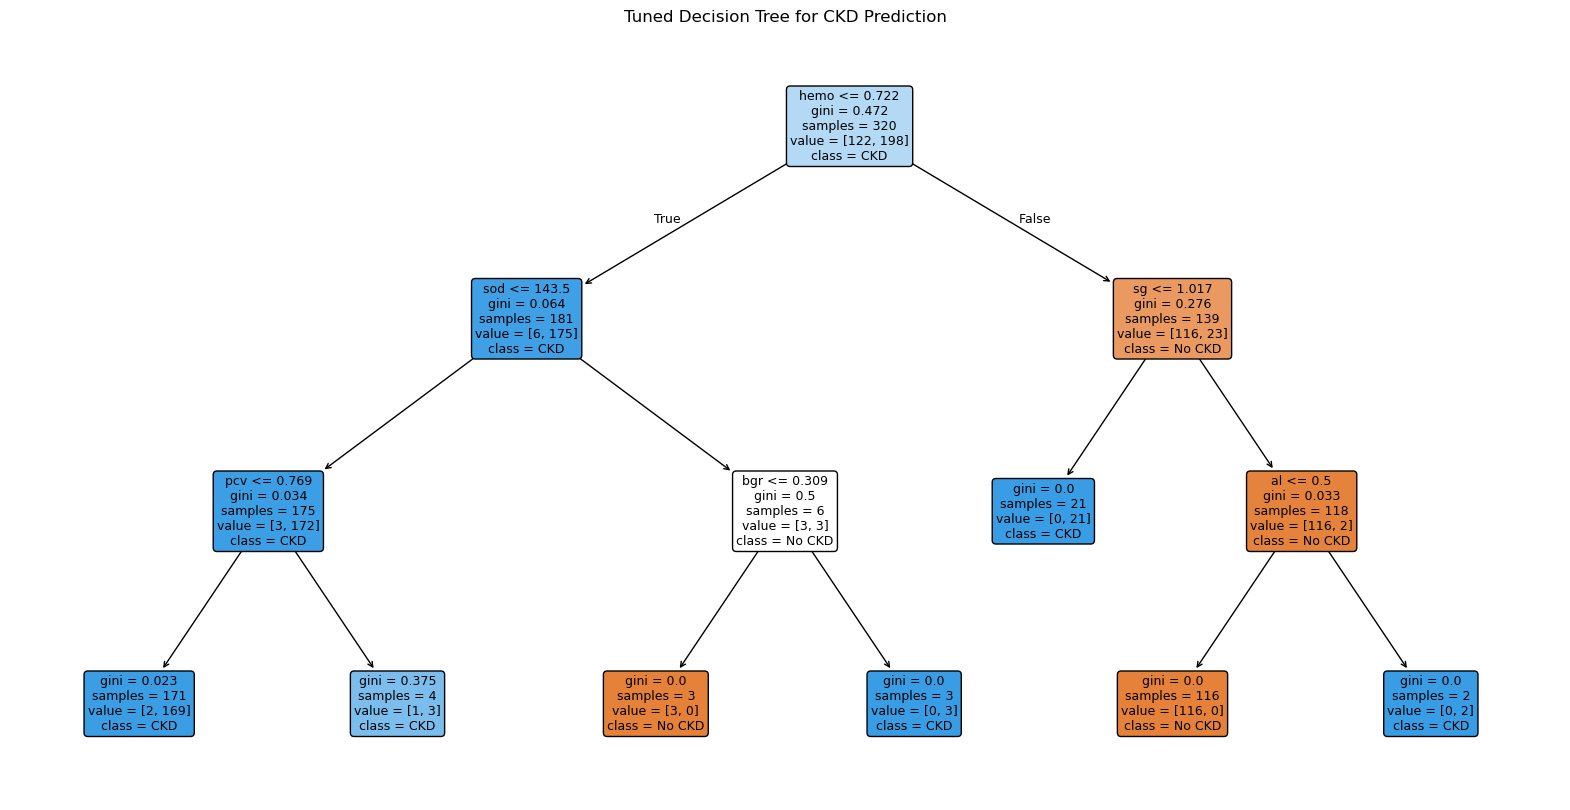

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_tuned,
    feature_names=X_train.columns,
    class_names=['No CKD', 'CKD'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Tuned Decision Tree for CKD Prediction')
plt.show()

### Observations

- The tuned Decision Tree is considerably simpler than the baseline model, with a maximum depth of 3 and 7 leaf nodes, making it easier to interpret.
- Hemoglobin (hemo) is selected as the root node, indicating that it is the most influential predictor for classifying patients with and without Chronic Kidney Disease in the tuned model.
- Additional variables, including sodium (sod), packed cell volume (pcv), blood glucose random (bgr), specific gravity (sg), and albumin (al), are used to further separate patients into CKD and non-CKD groups.
- The visualization demonstrates that hyperparameter tuning produced a simpler and more interpretable decision tree while maintaining the same predictive performance as the baseline Decision Tree on the testing dataset.

## Random Forest Classifier

The Random Forest classifier is trained using the encoded training dataset prepared in the previous step. During training, the algorithm builds multiple decision trees using random subsets of the training data and predictor variables. The final prediction is based on the combined predictions of multiple decision trees, which helps improve predictive accuracy and reduce overfitting. Once the model has been trained, it can be used to classify new patient records and identify individuals with and without Chronic Kidney Disease (CKD).

### Prepare the Features for Modeling

Before training the Random Forest model, the categorical predictor variables must be converted into numerical values because scikit-learn models cannot use text categories directly. Dummy variables are created for the categorical features while keeping the numerical variables unchanged. The encoded dataset is then divided into training and testing datasets so the Random Forest classifier can be trained and evaluated using the updated feature set.

In [36]:
# Convert categorical predictor variables into numerical dummy variables
X_encoded = pd.get_dummies(X, dtype=int)

# Create updated training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the updated dataset shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (320, 39)
Testing features: (80, 39)
Training target: (320,)
Testing target: (80,)


### Observations

- The categorical predictor variables were successfully converted into numerical dummy variables, increasing the number of predictor variables from 25 to 39.
- The encoded dataset was divided into 320 training observations (80%) and 80 testing observations (20%), maintaining the planned train-test split.
- The training and testing datasets are now prepared for developing and evaluating the Random Forest classification model.

### Train the Random Forest Classifier

The Random Forest classifier is trained using the encoded training dataset prepared in the previous step. During training, the algorithm builds multiple decision trees using random subsets of the training data and predictor variables. The final prediction is determined by combining the predictions from multiple decisions trees, which helps improve accuracy and reduce overfitting.

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Generate Predictions

After training the Random Forest classifier, the model is used to predict the CKD classification for the testing dataset. These predictions are then compared with the actual outcomes to assess the model's performance on previously unseen data.

In [38]:
# Generate predictions using the testing dataset
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

# Display the first 10 predictions
print("First 10 Predictions:", y_pred_rf[:10])

# Display the first 10 actual values
print("First 10 Actual Values:", y_test.values[:10])

First 10 Predictions: [0 1 1 0 1 1 0 1 1 1]
First 10 Actual Values: [0 1 1 0 1 1 0 1 1 1]


### Observations

- The Random Forest classifier successfully generated predictions for the testing dataset.
- Comparing the first 10 predictions with the actual values shows that the model correctly classified 9 of the first 10 observations.
- A complete evaluation using performance metrics such as accuracy, precision, recall, F1 score, and the confusion matrix is required to assess the model's overall performance.

## Evaluate the Random Forest Model

The performance of the Random Forest classifier is evaluated using several classification metrics. Accuracy measures the overall percentage of correct predictions, while the confusion matrix and classification report provide additional insight into how well the model identifies patients with and without Chronic Kidney Disease. These metrics help determine whether the model performs well and identify areas for improvement.

In [39]:
# Calculate the model accuracy
accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.975

Confusion Matrix:
[[28  2]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.96      1.00      0.98        50

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



### Observations

- The Random Forest classifier achieved an accuracy of 97.5%, correctly classifying 78 of the 80 testing observations.
- The confusion matrix shows that the model correctly identified all 50 CKD cases, resulting in a recall of 100% for the CKD class. It misclassified 2 non-CKD cases as CKD.
- The classification report indicates high overall performance, with a precision of 96%, recall of 100%, and an F1 score of 98% for the CKD class. These results demonstrate that the Random Forest model performs well in identifying patients with Chronic Kidney Disease while maintaining strong overall predictive performance.

### Feature Importance

Random Forest provides a feature importance score for each predictor variable based on its contribution to the model's classification decisions. Features with higher importance scores have a greater influence on predicting Chronic Kidney Disease (CKD). Examining feature importance helps identify the variables that contribute most to the model's performance and provides insight into the clinical factors associated with CKD.

In [40]:
# Create a DataFrame of feature importance scores
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display the top 10 most important features
feature_importance.head(10)

,Feature,Importance
10,hemo,0.208750
11,pcv,0.204047
2,sg,0.101124
7,sc,0.092348
13,rc,0.067777
3,al,0.055250
22,htn_no,0.039697
23,htn_yes,0.035694
24,dm_no,0.027407
6,bu,0.025109


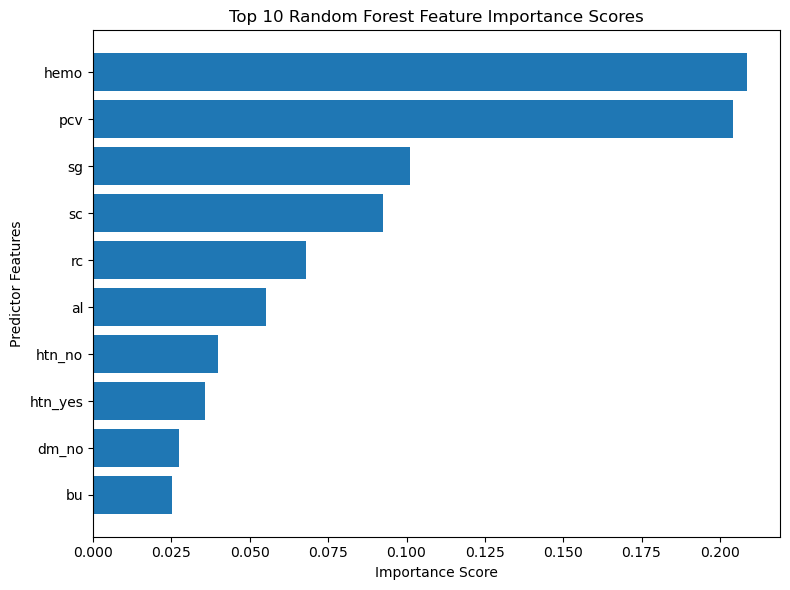

In [41]:
# Plot the top 10 most important features
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance['Feature'][:10][::-1],
    feature_importance['Importance'][:10][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Predictor Features")
plt.title("Top 10 Random Forest Feature Importance Scores")

plt.tight_layout()
plt.show()

### Observations

- The Random Forest model identified Hemoglobin (hemo) and Packed Cell Volume (pcv) as the two most important predictor variables, with importance scores of 0.209 and 0.207, respectively.
- Specific Gravity (sg), Serum Creatinine (sc), and Red Blood Cell Count (rc) were also identified as highly influential features, indicating that laboratory measurements play a significant role in predicting Chronic Kidney Disease.
- Additional predictors, including Albumin (al), Blood Glucose Random (bgr), Hypertension (htn), and Diabetes Mellitus (dm), contributed to the model's predictions but had lower relative importance.
- These results provide valuable insight into the variables that most strongly influence the Random Forest classifier and support the selection of important predictors for the reduced-feature models evaluated later in this project.

## Combined Logistic Regression and Random Forest Classifier Voting Model

The combined Logistic Regression and Random Forest classifier is an ensemble machine learning approach that leverages the strengths of both algorithms to improve the classification of patients with and without Chronic Kidney Disease (CKD). Logistic Regression provides a prediction based on the linear relationship between the input features and the target variable, while the Random Forest classifier captures non-linear relationships by combining the predictions of multiple decision trees. By combining Logistic Regression with Random Forest, the model aims to improve the accuracy of classifying patients with and without Chronic Kidney Disease (CKD). 

### Training the combined model

The combined model is trained using the encoded training dataset, where both the Logistic Regression and Random Forest models learn from the same training data. Weighting chosen in the model affect the weight applied to the Logistic Regression as compared to that of the Random Forest.  Because the Logistic Regression model was the best standalone model, it was weighted higher than that of the Random Forest.  Various weights were tested(1:1,3:1,1:2,2:1), before settling on the (2:1) as used in the final model. Each alternative iteration was slightly less than the chosen model, though none significantly altered the model performance. After training, the predictions from both models are combined to produce the final classification, improving the accuracy and reliability of Chronic Kidney Disease (CKD) prediction.

In [42]:
from sklearn.ensemble import VotingClassifier

#Scale Logistic
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic',LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

#Random Forest model
rf_voting_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


#Weight voting ensemble model
voting_model = VotingClassifier(
    estimators= [
        ('logistic',logistic_pipeline),
        ('random_forest', rf_voting_model)
    ],
    voting= 'soft',
    weights=[2,1]  #weighting Logistic more heavily
)

#Train the ensemble model
voting_model.fit(X_train, y_train)

#Generate predications
y_pred_voting = voting_model.predict(X_test)

#Predicted probabilities for ROC-AUC
y_prob_voting = voting_model.predict_proba(X_test)[:,1]

voting_model.fit(X_train, y_train)

,estimators,"[('logistic', ...), ('random_forest', ...)]"
,voting,'soft'
,weights,"[2, 1]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False


### Observations

- The combined Logistic Regression and Random Forest model was successfully trained using the encoded training dataset.
- Both models were trained on the same preprocessed data, ensuring consistent learning from the dataset.
- Both models use the same random state (42) to ensure reproducible results.
- The Random Forest model consists of 200 decision trees, using the Gini criterion and bootstrap sampling to improve prediction accuracy and reduce overfitting.

### Generate Predictions

After training the combined Logistic Regression and Random Forest model, predictions are generated for the testing dataset. The predictions from both models are combined to produce the final CKD classification, which is then compared with the actual outcomes to evaluate the model's performance on previously unseen data.

In [43]:
# Generate predictions using the testing dataset
y_pred_voting = voting_model.predict(X_test)

# Display the first 10 predictions
print("First 10 Predictions:", y_pred_voting[:10])

# Display the first 10 actual values
print("First 10 Actual Values:", y_test.values[:10])

First 10 Predictions: [0 1 1 0 1 1 0 1 1 1]
First 10 Actual Values: [0 1 1 0 1 1 0 1 1 1]


### Observations

- The combined Logistic Regression and Random Forest model successfully generated predictions for the testing dataset.
- The first 10 predictions matched all 10 actual classifications.
- Although the initial predictions are encouraging, the combined model should be evaluated on the entire testing dataset using performance metrics such as accuracy, precision, recall, and the F1-score to determine its overall effectiveness.

In [44]:
#Calculate accuracy

voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_precision = precision_score(y_test, y_pred_voting)
voting_recall = recall_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)
voting_roc_auc = roc_auc_score(y_test, y_prob_voting)

print("Accuracy:", voting_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_voting))

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

Accuracy: 0.9875

Confusion Matrix:
[[29  1]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



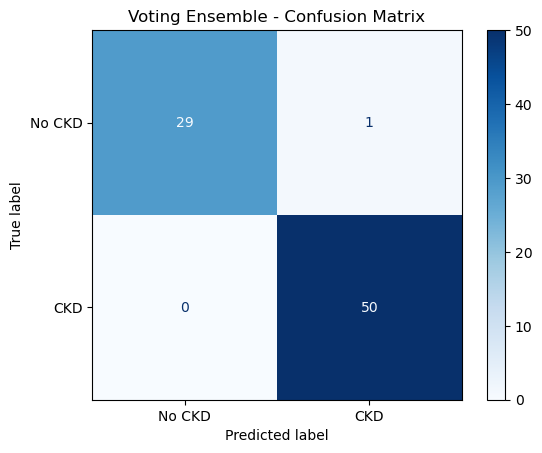

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    voting_model,
    X_test,
    y_test,
    display_labels= ['No CKD', 'CKD'],
    cmap='Blues'
    )

plt.title('Voting Ensemble - Confusion Matrix')
plt.show()

### Observations

- The combined Logistic Regression and Random Forest model achieved an accuracy of 98.75%, correctly classifying 79 out of 80 testing observations.
- The confusion matrix shows that the model correctly identified all 50 CKD cases, achieving a recall of 100% for the CKD class. Only one non-CKD case was incorrectly classified as CKD.
- The classification report indicates excellent performance, with a precision of 98%, recall of 100%, and an F1-score of 99% for the CKD class, demonstrating the model's ability to accurately detect patients with Chronic Kidney Disease.

## MODEL PERFORMANCE COMPARISON

### Training and Testing Accuracy

The training and testing accuracy of each model are compared to evaluate predictive performance and identify possible overfitting. A large difference between training and testing accuracy may indicate that a model learned the training data too closely and may not generalize well to new observations.

In [46]:
# Calculate training accuracy for each model
rf_train_accuracy = accuracy_score(
    y_train,
    rf_model.predict(X_train)
)

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_model.predict(X_train)
)

dt_train_accuracy = accuracy_score(
    y_train,
    dt_model.predict(X_train)
)

dt_tuned_train_accuracy = accuracy_score(
    y_train,
    dt_tuned.predict(X_train)
)
voting_model_accuracy = accuracy_score(
    y_train,
    voting_model.predict(X_train)
)
# Create a model comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree',
        'Random Forest',
        'Voting Model'
    ],
    'Training Accuracy': [
        logistic_train_accuracy,
        dt_train_accuracy,
        dt_tuned_train_accuracy,
        rf_train_accuracy,
        voting_model_accuracy
    ],
    'Testing Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_voting)
    ]
})

model_comparison.round(4)

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.9969,0.9875
1,Decision Tree,1.0000,0.9500
2,Tuned Decision Tree,0.9906,0.9500
3,Random Forest,1.0000,0.9750
4,Voting Model,0.9969,0.9875


### Observations

- The Random Forest model achieved a training accuracy of 100% and a testing accuracy of 97.5%, indicating excellent predictive performance with a slight decrease on unseen data.
- The Logistic Regression model achieved a training accuracy of 99.69% and the highest testing accuracy of 98.75%, demonstrating excellent generalization and the best overall performance among the models evaluated.
- The Decision Tree and Tuned Decision Tree models achieved testing accuracies of 95.0%. Although the tuned model reduced the complexity of the tree, its predictive performance remained similar to the baseline model.
- Overall, the relatively small differences between training and testing accuracy indicate that all four models generalized well to the testing dataset, with Logistic Regression providing the best balance between training performance and testing accuracy.

### Comparison of Model Performance

To identify the best-performing classifier, the evaluation metrics from each machine learning model are summarized and compared. Accuracy, precision, recall, F1 score, and ROC-AUC provide a comprehensive assessment of each model's predictive performance and ability to correctly classify patients with and without Chronic Kidney Disease.

In [47]:
#Comparing models
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Voting Model"
    ],
    "Training Accuracy": [
        logistic_train_accuracy,
        dt_train_accuracy,
        dt_tuned_train_accuracy,
        rf_train_accuracy,
        voting_model_accuracy
    ],
    "Testing Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_voting)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt_tuned),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_voting)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt_tuned),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_voting)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt_tuned),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_voting)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_dt_tuned),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_voting)
    ]
})

comparison.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9969,0.9875,0.9804,1.00,0.9901,0.9773
1,Decision Tree,1.0000,0.9500,0.9600,0.96,0.9600,0.9467
2,Tuned Decision Tree,0.9906,0.9500,0.9600,0.96,0.9600,0.9480
3,Random Forest,1.0000,0.9750,0.9615,1.00,0.9804,0.9717
4,Voting Model,0.9969,0.9875,0.9804,1.00,0.9901,0.9720


### Observations

- The Logistic Regression model and the Voting model achieved matching scores with the highest testing accuracy (98.75%),  the highest F1 score (99.01%), with the ROC-AUC coming in slightly higher for the Logistic Regression, demonstrating the best overall predictive performance among the models evaluated.
- The Random Forest model also performed exceptionally well, achieving 97.50% testing accuracy and 100% recall, indicating that it successfully identified all CKD cases in the testing dataset.
- Both the Decision Tree and Tuned Decision Tree models achieved 95.00% testing accuracy with identical precision, recall, and F1 scores. Hyperparameter tuning simplified the Decision Tree but did not improve its predictive performance.
- Overall, the comparison indicates that Logistic Regression provided the best balance of accuracy, precision, recall, and F1 score, while being the simplest model to run, making it the strongest candidate for predicting Chronic Kidney Disease in this dataset. 

## FINAL MODEL SELECTION

After comparing the performance of the five classification models, Logistic Regression was selected as the final model for predicting Chronic Kidney Disease. It achieved the highest testing accuracy (98.75%), the highest F1 score (99.01%), as well as the highest ROC-AUC score, while maintaining perfect recall for CKD cases. While the combined Logistic and Random Forest Voting model performed equally well, the Logistic Regression provides matching results as a simpler model to implement.  Although Random Forest also performed exceptionally well, Logistic Regression provided the best overall balance between predictive accuracy and generalization on the testing dataset. 

## PROJECT LIMITATIONS

Although the models achieved strong predictive performance, this study has several limitations. The dataset contains only 400 observations, which may limit how well the models generalize to other patient populations. In addition, the models were trained using a single dataset without external validation. Future work could include testing additional machine learning algorithms, collecting larger datasets, and validating the models using independent clinical data. 

## CONCLUSION 

This project successfully developed and evaluated multiple machine learning models for predicting Chronic Kidney Disease. After comparing Random Forest, Logistic Regression, Decision Tree, Tuned Decision Tree, and a combined Logistic Regression Random Forest Voting model, Logistic Regression demonstrated the strongest overall performance based on testing accuracy, precision, recall, and F1 score. The results suggest that machine learning techniques can effectively support the early identification of Chronic Kidney Disease and may assist healthcare professionals in making more informed clinical decisions. 
In application, the models could be expanded to determine more readily the diagnoses of CKD, but also be expanded to include the scope of early warning signs. Utilizing the indicators, data collection could be refined to capture test results that may express a patient's approaching limits to indicate warning signs. Capturing these early warning signs, given the key determining features could allow healthcare providers the ability to successfully deter further advancement of kidney damage.